In [15]:
import os
import glob
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import cv2
from skimage import io, morphology
from skimage.filters import frangi
from scipy import ndimage

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from imblearn.under_sampling import RandomUnderSampler

warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)

WCZYTAJ_GOTOWE_MODELE = False

KATALOG_DANYCH = "resource/CHASEDB1"

LICZBA_OBRAZOW_TRENINGOWYCH = 20
ROZMIAR_WYCINKA = 5
MAKS_LICZBA_PROBEK = 10000000

ROZMIAR_WEJSCIA_UNET = 512
LICZBA_EPOK_UNET = 256
ROZMIAR_BATCHA_UNET = 2

os.makedirs("models", exist_ok=True)
SCIEZKA_MODELU_RF = "models/rf_pipeline.joblib"
SCIEZKA_MODELU_UNET = "models/unet_weights.pth"

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["image.cmap"] = "gray"

In [16]:
def wczytaj_liste_danych(katalog_danych):
    sciezki_obrazow = sorted(glob.glob(os.path.join(katalog_danych, "images", "*.png")))
    lista_danych = []
    for sciezka_obrazu in sciezki_obrazow:
        nazwa_pliku = os.path.basename(sciezka_obrazu)
        nazwa_bez_rozszerzenia = os.path.splitext(nazwa_pliku)[0]
        sciezka_maski = os.path.join(katalog_danych, "masks", nazwa_bez_rozszerzenia + "_1stHO.png")
        if os.path.exists(sciezka_maski):
            lista_danych.append({
                "id": nazwa_bez_rozszerzenia,
                "obraz": sciezka_obrazu,
                "maska": sciezka_maski,
            })
    return lista_danych


def utworz_maske_pola_widzenia(obraz_rgb):
    obraz_szary = cv2.cvtColor(obraz_rgb, cv2.COLOR_RGB2GRAY)
    prog_jasnosci = 25
    maska = obraz_szary > prog_jasnosci
    maska = ndimage.binary_fill_holes(maska)
    maska = morphology.binary_erosion(maska, morphology.disk(3))
    maska = morphology.remove_small_objects(maska, 5000)
    return maska


def wczytaj_obraz(dane):
    obraz_rgb = io.imread(dane["obraz"])[:, :, :3]
    maska_z_pliku = io.imread(dane["maska"])
    maska_ekspercka = maska_z_pliku > 0
    maska_pola_widzenia = utworz_maske_pola_widzenia(obraz_rgb)
    return obraz_rgb, maska_ekspercka, maska_pola_widzenia


wszystkie_dane = wczytaj_liste_danych(KATALOG_DANYCH)
dane_treningowe = wszystkie_dane[:LICZBA_OBRAZOW_TRENINGOWYCH]
dane_testowe = wszystkie_dane[LICZBA_OBRAZOW_TRENINGOWYCH:]

print("Obrazow razem:", len(wszystkie_dane))
print("Treningowych:", len(dane_treningowe), "| testowych:", len(dane_testowe))
print("Testowe:", [dane["id"] for dane in dane_testowe])

Obrazow razem: 28
Treningowych: 20 | testowych: 8
Testowe: ['Image_11L', 'Image_11R', 'Image_12L', 'Image_12R', 'Image_13L', 'Image_13R', 'Image_14L', 'Image_14R']


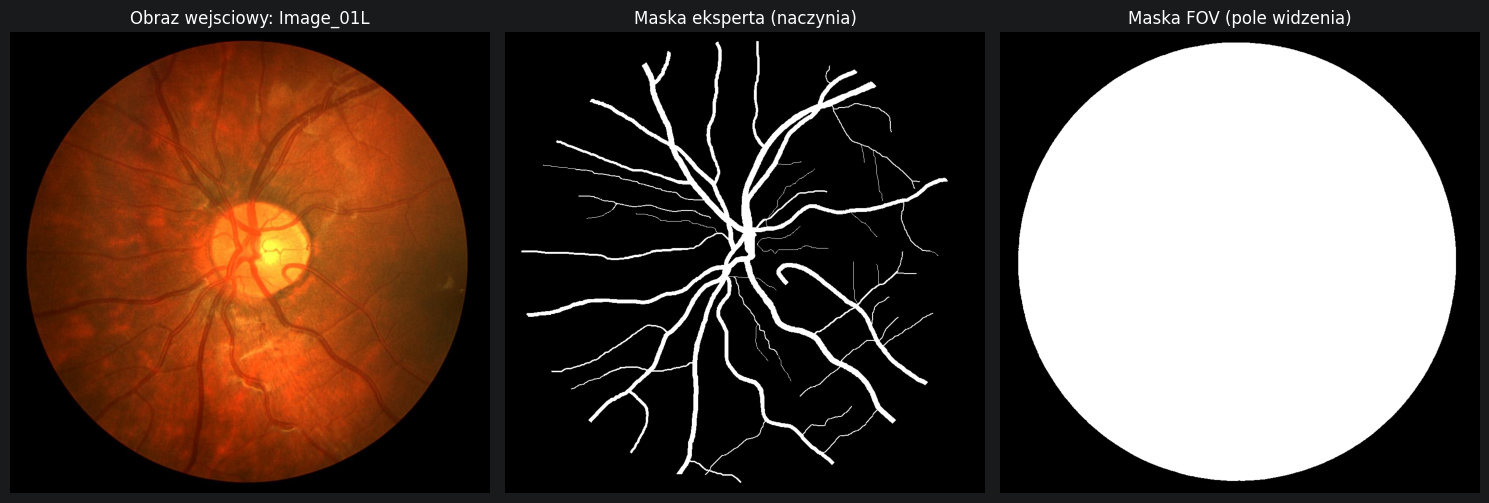

Udzial pikseli naczyn w polu widzenia: 10.14 %


In [17]:
obraz_rgb, maska_ekspercka, maska_pola_widzenia = wczytaj_obraz(wszystkie_dane[0])

figura, osie = plt.subplots(1, 3, figsize=(15, 5))
osie[0].imshow(obraz_rgb)
osie[0].set_title("Obraz wejsciowy: " + wszystkie_dane[0]["id"])
osie[1].imshow(maska_ekspercka)
osie[1].set_title("Maska eksperta (naczynia)")
osie[2].imshow(maska_pola_widzenia)
osie[2].set_title("Maska FOV (pole widzenia)")
for pojedyncza_os in osie:
    pojedyncza_os.axis("off")
plt.tight_layout()
plt.show()

procent_naczyn = maska_ekspercka[maska_pola_widzenia].mean() * 100
print("Udzial pikseli naczyn w polu widzenia:", round(procent_naczyn, 2), "%")

In [18]:
def policz_macierz_pomylek(predykcja, maska_ekspercka, maska_pola_widzenia):
    naczynia_predykcji = predykcja & maska_pola_widzenia
    naczynia_eksperta = maska_ekspercka & maska_pola_widzenia
    tlo_eksperta = (~maska_ekspercka) & maska_pola_widzenia

    prawdziwie_dodatnie = int(np.sum(naczynia_predykcji & naczynia_eksperta))
    falszywie_dodatnie = int(np.sum(naczynia_predykcji & tlo_eksperta))
    falszywie_ujemne = int(np.sum((~predykcja) & naczynia_eksperta))
    prawdziwie_ujemne = int(np.sum((~predykcja) & tlo_eksperta))
    return prawdziwie_dodatnie, falszywie_dodatnie, falszywie_ujemne, prawdziwie_ujemne


def policz_metryki(predykcja, maska_ekspercka, maska_pola_widzenia):
    tp, fp, fn, tn = policz_macierz_pomylek(predykcja, maska_ekspercka, maska_pola_widzenia)
    epsilon = 1e-9

    czulosc = tp / (tp + fn + epsilon)
    swoistosc = tn / (tn + fp + epsilon)
    dokladnosc = (tp + tn) / (tp + tn + fp + fn + epsilon)
    precyzja = tp / (tp + fp + epsilon)
    dokladnosc_zbalansowana = (czulosc + swoistosc) / 2
    srednia_geometryczna = np.sqrt(czulosc * swoistosc)
    dice = 2 * tp / (2 * tp + fp + fn + epsilon)
    mianownik_mcc = np.sqrt(float(tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)) + epsilon
    mcc = (tp * tn - fp * fn) / mianownik_mcc

    return {
        "accuracy": dokladnosc,
        "sensitivity": czulosc,
        "specificity": swoistosc,
        "precision": precyzja,
        "balanced_acc": dokladnosc_zbalansowana,
        "g_mean": srednia_geometryczna,
        "dice": dice,
        "mcc": mcc,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }


def ocen_metode(funkcja_predykcji, lista_danych, nazwa):
    wiersze = []
    for dane in lista_danych:
        obraz_rgb, maska_ekspercka, maska_pola_widzenia = wczytaj_obraz(dane)
        predykcja = funkcja_predykcji(obraz_rgb, maska_pola_widzenia).astype(bool)
        metryki = policz_metryki(predykcja, maska_ekspercka, maska_pola_widzenia)
        metryki["id"] = dane["id"]
        wiersze.append(metryki)

    tabela = pd.DataFrame(wiersze).set_index("id")
    wiersz_sredni = tabela.mean(numeric_only=True)
    wiersz_sredni.name = "MEAN"
    tabela = pd.concat([tabela, wiersz_sredni.to_frame().T])
    tabela.attrs["name"] = nazwa
    return tabela


def pokaz_nakladke(obraz_rgb, predykcja, maska_ekspercka, maska_pola_widzenia, tytul):
    predykcja = predykcja & maska_pola_widzenia
    maska_ekspercka = maska_ekspercka & maska_pola_widzenia

    nakladka = obraz_rgb.copy()
    nakladka[maska_ekspercka & predykcja] = [0, 255, 0]
    nakladka[maska_ekspercka & ~predykcja] = [255, 0, 0]
    nakladka[~maska_ekspercka & predykcja] = [0, 0, 255]

    figura, osie = plt.subplots(1, 3, figsize=(16, 5))
    osie[0].imshow(obraz_rgb)
    osie[0].set_title("Obraz wejsciowy")
    osie[1].imshow(predykcja)
    osie[1].set_title("Maska binarna - " + tytul)
    osie[2].imshow(nakladka)
    osie[2].set_title("Nakladka: TP=zielony, FN=czerwony, FP=niebieski")
    for pojedyncza_os in osie:
        pojedyncza_os.axis("off")
    plt.tight_layout()
    plt.show()


def pokaz_wykres_slupkowy(tabela, tytul):
    nazwy_metryk = ["accuracy", "sensitivity", "specificity", "balanced_acc", "g_mean", "dice"]
    srednie_metryki = tabela.loc["MEAN", nazwy_metryk]

    os_wykresu = srednie_metryki.plot(kind="bar", color="steelblue", figsize=(9, 4), ylim=(0, 1))
    os_wykresu.set_title(tytul)
    os_wykresu.set_ylabel("wartosc")
    plt.xticks(rotation=30, ha="right")
    for numer, wartosc in enumerate(srednie_metryki):
        os_wykresu.text(numer, wartosc + 0.01, f"{wartosc:.3f}", ha="center", fontsize=9)
    plt.tight_layout()
    plt.show()

In [19]:
def przetwarzanie_wstepne(obraz_rgb):
    kanal_zielony = obraz_rgb[:, :, 1]
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4, 4))
    obraz_wzmocniony = clahe.apply(kanal_zielony)
    obraz_wzmocniony = cv2.medianBlur(obraz_wzmocniony, 11)
    return obraz_wzmocniony


def filtr_frangiego(obraz_wzmocniony, maska_pola_widzenia):
    obraz_znormalizowany = obraz_wzmocniony.astype(np.float32) / 255.0
    odpowiedz = frangi(obraz_znormalizowany, sigmas=range(4, 8), black_ridges=True)
    odpowiedz = cv2.normalize(odpowiedz, None, 0, 1, cv2.NORM_MINMAX)
    odpowiedz[~maska_pola_widzenia] = 0
    return odpowiedz


def przetwarzanie_koncowe(odpowiedz_frangiego, maska_pola_widzenia, percentyl=91):
    wartosci_w_polu = odpowiedz_frangiego[maska_pola_widzenia]
    prog = np.percentile(wartosci_w_polu, percentyl)

    maska_binarna = (odpowiedz_frangiego > prog) & maska_pola_widzenia
    maska_binarna = morphology.remove_small_objects(maska_binarna, 80)
    maska_binarna = morphology.binary_closing(maska_binarna, morphology.disk(1))
    maska_binarna = morphology.remove_small_objects(maska_binarna, 160)
    return maska_binarna


def metoda_klasyczna(obraz_rgb, maska_pola_widzenia):
    obraz_wzmocniony = przetwarzanie_wstepne(obraz_rgb)
    odpowiedz_frangiego = filtr_frangiego(obraz_wzmocniony, maska_pola_widzenia)
    return przetwarzanie_koncowe(odpowiedz_frangiego, maska_pola_widzenia)

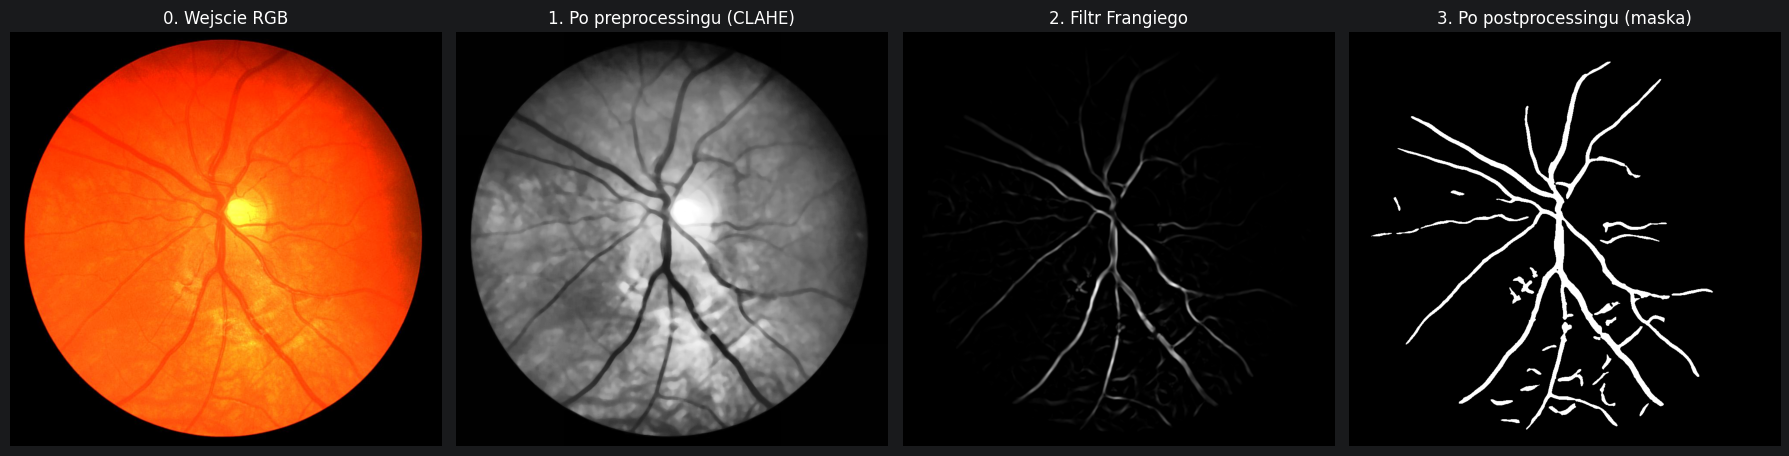

In [20]:
obraz_rgb, maska_ekspercka, maska_pola_widzenia = wczytaj_obraz(dane_testowe[0])
obraz_wzmocniony = przetwarzanie_wstepne(obraz_rgb)
odpowiedz_frangiego = filtr_frangiego(obraz_wzmocniony, maska_pola_widzenia)
maska_binarna = przetwarzanie_koncowe(odpowiedz_frangiego, maska_pola_widzenia)

figura, osie = plt.subplots(1, 4, figsize=(18, 5))
osie[0].imshow(obraz_rgb)
osie[0].set_title("0. Wejscie RGB")
osie[1].imshow(obraz_wzmocniony)
osie[1].set_title("1. Po preprocessingu (CLAHE)")
osie[2].imshow(odpowiedz_frangiego)
osie[2].set_title("2. Filtr Frangiego")
osie[3].imshow(maska_binarna)
osie[3].set_title("3. Po postprocessingu (maska)")
for pojedyncza_os in osie:
    pojedyncza_os.axis("off")
plt.tight_layout()
plt.show()

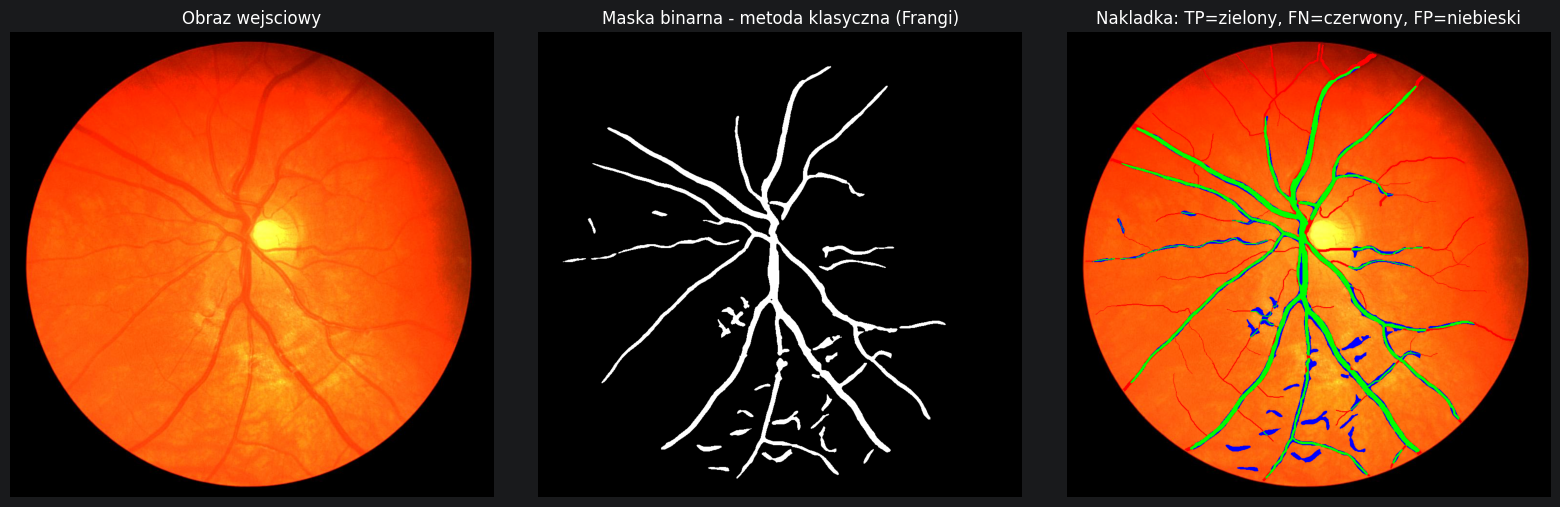

In [21]:
pokaz_nakladke(obraz_rgb, maska_binarna, maska_ekspercka, maska_pola_widzenia, tytul="metoda klasyczna (Frangi)")

In [22]:
czas_startu = time.time()
wyniki_klasyczne = ocen_metode(metoda_klasyczna, dane_testowe, nazwa="Frangi")
print("Czas:", round(time.time() - czas_startu, 1), "s")
wyniki_klasyczne.round(4)

Czas: 4.6 s


,accuracy,sensitivity,specificity,precision,balanced_acc,g_mean,dice,mcc,TP,FP,FN,TN
Image_11L,0.9518,0.7195,0.9713,0.6785,0.8454,0.8360,0.6984,0.6725,36653.000,17371.000,14292.00,588009.000
Image_11R,0.9543,0.7482,0.9717,0.6903,0.8599,0.8527,0.7181,0.6940,38099.000,17090.000,12823.00,586925.000
Image_12L,0.9371,0.6099,0.9771,0.7650,0.7935,0.7720,0.6787,0.6494,40694.000,12504.000,26029.00,533086.000
Image_12R,0.9426,0.6324,0.9799,0.7912,0.8062,0.7872,0.7030,0.6768,44429.000,11724.000,25822.00,571622.000
Image_13L,0.9405,0.6313,0.9712,0.6848,0.8012,0.7830,0.6569,0.6250,37079.000,17067.000,21658.00,574941.000
Image_13R,0.9385,0.6242,0.9707,0.6855,0.7974,0.7784,0.6534,0.6205,37731.000,17307.000,22719.00,572587.000
Image_14L,0.9475,0.6644,0.9791,0.7807,0.8218,0.8066,0.7179,0.6919,43754.000,12287.000,22101.00,576911.000
Image_14R,0.9477,0.6719,0.9760,0.7422,0.8240,0.8098,0.7053,0.6777,36528.000,12689.000,17838.00,517046.000
MEAN,0.9450,0.6627,0.9746,0.7273,0.8187,0.8032,0.6915,0.6635,39370.875,14754.875,20410.25,565140.875


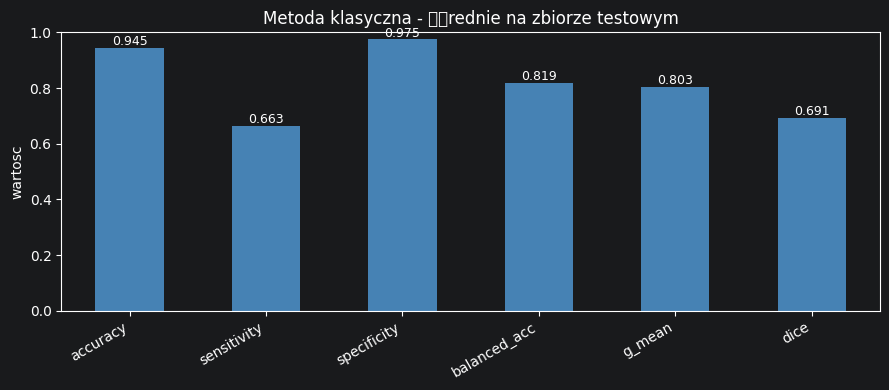

Macierz prawdziwo﷿﷿ci (suma po zbiorze testowym):
                odp: naczynie  odp: tlo
dana: naczynie         314967    163282
dana: tlo              118039   4521127


In [23]:
pokaz_wykres_slupkowy(wyniki_klasyczne, "Metoda klasyczna - ﷿﷿rednie na zbiorze testowym")

print("Macierz prawdziwo﷿﷿ci (suma po zbiorze testowym):")
liczba_testowych = len(dane_testowe)
tp = int(wyniki_klasyczne.loc["MEAN", "TP"] * liczba_testowych)
fp = int(wyniki_klasyczne.loc["MEAN", "FP"] * liczba_testowych)
fn = int(wyniki_klasyczne.loc["MEAN", "FN"] * liczba_testowych)
tn = int(wyniki_klasyczne.loc["MEAN", "TN"] * liczba_testowych)
print(pd.DataFrame(
    [[tp, fn], [fp, tn]],
    index=["dana: naczynie", "dana: tlo"],
    columns=["odp: naczynie", "odp: tlo"],
))

In [24]:
def mapy_cech_momentow(obraz_szary, rozmiar=5):
    promien = rozmiar // 2
    wspolrzedne_y, wspolrzedne_x = np.mgrid[-promien:promien + 1, -promien:promien + 1]
    wspolrzedne_x = wspolrzedne_x.astype(np.float32)
    wspolrzedne_y = wspolrzedne_y.astype(np.float32)

    def moment_surowy(p, q):
        jadro = (wspolrzedne_x ** p) * (wspolrzedne_y ** q)
        return cv2.filter2D(obraz_szary, cv2.CV_32F, jadro, borderType=cv2.BORDER_REFLECT)

    epsilon = 1e-7

    m00 = moment_surowy(0, 0)
    m10 = moment_surowy(1, 0)
    m01 = moment_surowy(0, 1)
    m20 = moment_surowy(2, 0)
    m02 = moment_surowy(0, 2)
    m11 = moment_surowy(1, 1)
    m30 = moment_surowy(3, 0)
    m03 = moment_surowy(0, 3)
    m21 = moment_surowy(2, 1)
    m12 = moment_surowy(1, 2)

    srodek_x = m10 / (m00 + epsilon)
    srodek_y = m01 / (m00 + epsilon)

    mu20 = m20 - srodek_x * m10
    mu02 = m02 - srodek_y * m01
    mu11 = m11 - srodek_x * m01
    mu30 = m30 - 3 * srodek_x * m20 + 2 * srodek_x * srodek_x * m10
    mu03 = m03 - 3 * srodek_y * m02 + 2 * srodek_y * srodek_y * m01
    mu21 = m21 - 2 * srodek_x * m11 - srodek_y * m20 + 2 * srodek_x * srodek_x * m01
    mu12 = m12 - 2 * srodek_y * m11 - srodek_x * m02 + 2 * srodek_y * srodek_y * m10

    def znormalizuj(moment_centralny, p, q):
        return moment_centralny / ((m00 + epsilon) ** (1 + (p + q) / 2.0))

    n20 = znormalizuj(mu20, 2, 0)
    n02 = znormalizuj(mu02, 0, 2)
    n11 = znormalizuj(mu11, 1, 1)
    n30 = znormalizuj(mu30, 3, 0)
    n03 = znormalizuj(mu03, 0, 3)
    n21 = znormalizuj(mu21, 2, 1)
    n12 = znormalizuj(mu12, 1, 2)

    hu1 = n20 + n02
    hu2 = (n20 - n02) ** 2 + 4 * n11 ** 2
    hu3 = (n30 - 3 * n12) ** 2 + (3 * n21 - n03) ** 2
    hu4 = (n30 + n12) ** 2 + (n21 + n03) ** 2
    hu5 = ((n30 - 3 * n12) * (n30 + n12) * ((n30 + n12) ** 2 - 3 * (n21 + n03) ** 2)
           + (3 * n21 - n03) * (n21 + n03) * (3 * (n30 + n12) ** 2 - (n21 + n03) ** 2))
    hu6 = ((n20 - n02) * ((n30 + n12) ** 2 - (n21 + n03) ** 2)
           + 4 * n11 * (n30 + n12) * (n21 + n03))
    hu7 = ((3 * n21 - n03) * (n30 + n12) * ((n30 + n12) ** 2 - 3 * (n21 + n03) ** 2)
           - (n30 - 3 * n12) * (n21 + n03) * (3 * (n30 + n12) ** 2 - (n21 + n03) ** 2))
    momenty_hu = [hu1, hu2, hu3, hu4, hu5, hu6, hu7]

    momenty_hu = [np.sign(hu) * np.log1p(np.abs(hu)) for hu in momenty_hu]

    momenty_centralne = [n20, n02, n11, n30, n03, n21, n12]
    return momenty_centralne + momenty_hu


NAZWY_CECH = (
    ["mean_g", "var_g", "var_r", "var_b", "frangi"]
    + ["eta_20", "eta_02", "eta_11", "eta_30", "eta_03", "eta_21", "eta_12"]
    + ["hu1", "hu2", "hu3", "hu4", "hu5", "hu6", "hu7"]
)


def wyznacz_cechy(obraz_rgb, maska_pola_widzenia, rozmiar=ROZMIAR_WYCINKA):
    obraz_wzmocniony = przetwarzanie_wstepne(obraz_rgb)
    obraz_szary = obraz_wzmocniony.astype(np.float32) / 255.0
    rozmiar_okna = (rozmiar, rozmiar)

    lista_cech = []

    srednia_zielony = cv2.boxFilter(obraz_szary, -1, rozmiar_okna, borderType=cv2.BORDER_REFLECT)
    srednia_kwadratow = cv2.boxFilter(obraz_szary * obraz_szary, -1, rozmiar_okna, borderType=cv2.BORDER_REFLECT)
    wariancja_zielony = srednia_kwadratow - srednia_zielony ** 2
    lista_cech.append(srednia_zielony)
    lista_cech.append(np.maximum(wariancja_zielony, 0))

    for numer_kanalu in (0, 2):
        kanal = obraz_rgb[:, :, numer_kanalu].astype(np.float32) / 255.0
        srednia_kanalu = cv2.boxFilter(kanal, -1, rozmiar_okna, borderType=cv2.BORDER_REFLECT)
        srednia_kwadratow_kanalu = cv2.boxFilter(kanal * kanal, -1, rozmiar_okna, borderType=cv2.BORDER_REFLECT)
        wariancja_kanalu = srednia_kwadratow_kanalu - srednia_kanalu ** 2
        lista_cech.append(np.maximum(wariancja_kanalu, 0))

    lista_cech.append(filtr_frangiego(obraz_wzmocniony, maska_pola_widzenia))

    lista_cech += mapy_cech_momentow(obraz_szary, rozmiar)

    tensor_cech = np.stack(lista_cech, axis=-1).astype(np.float32)
    tensor_cech[~maska_pola_widzenia] = 0
    return tensor_cech

In [25]:
def zbuduj_zbior_treningowy(lista_danych, liczba_obrazow, maks_probek):
    lista_cech = []
    lista_etykiet = []
    probek_na_obraz = maks_probek // liczba_obrazow

    for dane in lista_danych[:liczba_obrazow]:
        obraz_rgb, maska_ekspercka, maska_pola_widzenia = wczytaj_obraz(dane)
        tensor_cech = wyznacz_cechy(obraz_rgb, maska_pola_widzenia)
        liczba_cech = tensor_cech.shape[2]

        cechy_wszystkich_pikseli = tensor_cech.reshape(-1, liczba_cech)
        etykiety_wszystkich_pikseli = maska_ekspercka.reshape(-1).astype(np.uint8)
        maska_plaska = maska_pola_widzenia.reshape(-1)
        indeksy_w_polu = np.where(maska_plaska)[0]

        cechy_w_polu = cechy_wszystkich_pikseli[indeksy_w_polu]
        etykiety_w_polu = etykiety_wszystkich_pikseli[indeksy_w_polu]

        undersampler = RandomUnderSampler(random_state=42)
        cechy_zbalansowane, etykiety_zbalansowane = undersampler.fit_resample(cechy_w_polu, etykiety_w_polu)

        if len(etykiety_zbalansowane) > probek_na_obraz:
            wybrane = np.random.choice(len(etykiety_zbalansowane), probek_na_obraz, replace=False)
            cechy_zbalansowane = cechy_zbalansowane[wybrane]
            etykiety_zbalansowane = etykiety_zbalansowane[wybrane]

        lista_cech.append(cechy_zbalansowane)
        lista_etykiet.append(etykiety_zbalansowane)

    cechy_treningowe = np.vstack(lista_cech)
    etykiety_treningowe = np.concatenate(lista_etykiet)
    return cechy_treningowe, etykiety_treningowe

cechy_treningowe, etykiety_treningowe = zbuduj_zbior_treningowy(dane_treningowe, LICZBA_OBRAZOW_TRENINGOWYCH, MAKS_LICZBA_PROBEK)

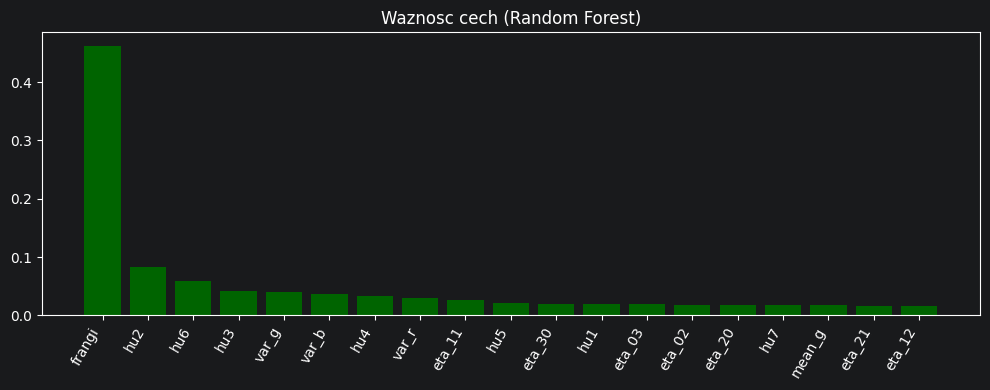

In [26]:
if WCZYTAJ_GOTOWE_MODELE and os.path.exists(SCIEZKA_MODELU_RF):
    klasyfikator = joblib.load(SCIEZKA_MODELU_RF)
    print("Zaladowano model RF z:", SCIEZKA_MODELU_RF)
else:
    klasyfikator = Pipeline([
        ("las_losowy", RandomForestClassifier(
            n_estimators=128,
            max_depth=32,
            n_jobs=-1,
            class_weight="balanced",
            random_state=42,
        )),
    ])
    klasyfikator.fit(cechy_treningowe, etykiety_treningowe)
    joblib.dump(klasyfikator, SCIEZKA_MODELU_RF)

waznosc_cech = klasyfikator.named_steps["las_losowy"].feature_importances_
kolejnosc = np.argsort(waznosc_cech)[::-1]
plt.figure(figsize=(10, 4))
plt.bar(range(len(waznosc_cech)), waznosc_cech[kolejnosc], color="darkgreen")
plt.xticks(range(len(waznosc_cech)), [NAZWY_CECH[i] for i in kolejnosc], rotation=60, ha="right")
plt.title("Waznosc cech (Random Forest)")
plt.tight_layout()
plt.show()

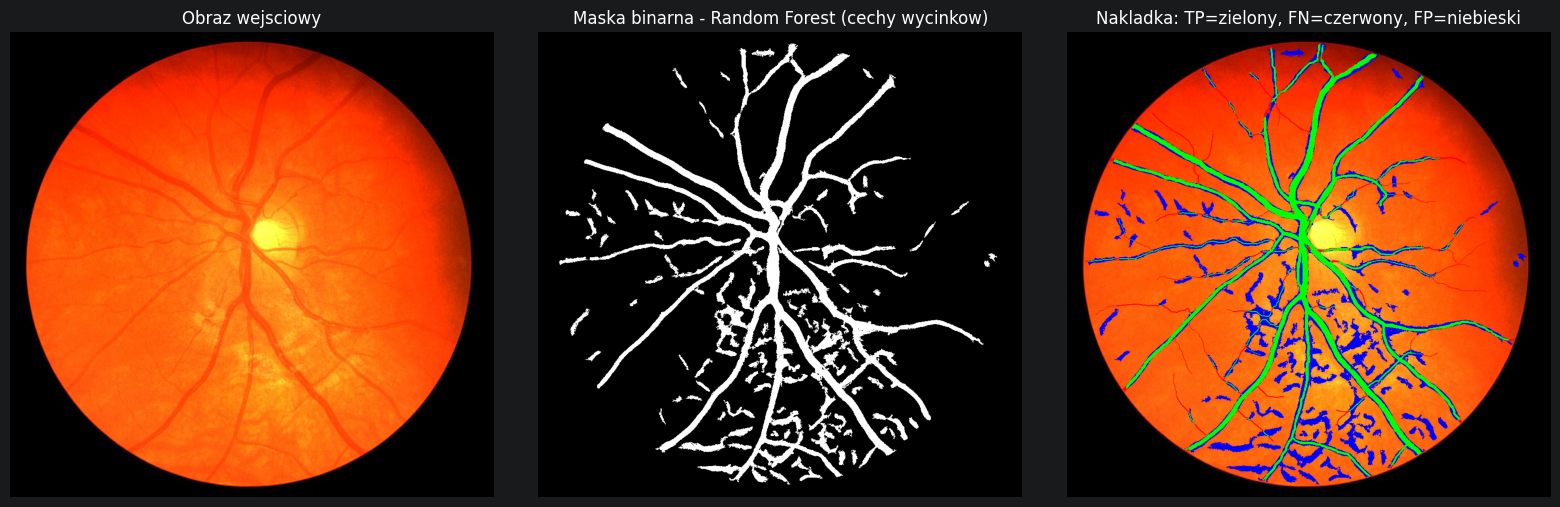

In [27]:
def predykcja_random_forest(obraz_rgb, maska_pola_widzenia):
    tensor_cech = wyznacz_cechy(obraz_rgb, maska_pola_widzenia)
    wysokosc, szerokosc, liczba_cech = tensor_cech.shape

    predykcja = np.zeros((wysokosc, szerokosc), dtype=bool)
    indeksy_w_polu = np.where(maska_pola_widzenia.reshape(-1))[0]
    cechy_w_polu = tensor_cech.reshape(-1, liczba_cech)[indeksy_w_polu]

    etykiety_w_polu = klasyfikator.predict(cechy_w_polu).astype(bool)
    predykcja_plaska = predykcja.reshape(-1)
    predykcja_plaska[indeksy_w_polu] = etykiety_w_polu
    predykcja = predykcja_plaska.reshape(wysokosc, szerokosc)

    predykcja = morphology.remove_small_objects(predykcja, 100)
    return predykcja


obraz_rgb, maska_ekspercka, maska_pola_widzenia = wczytaj_obraz(dane_testowe[0])
predykcja_rf = predykcja_random_forest(obraz_rgb, maska_pola_widzenia)
pokaz_nakladke(obraz_rgb, predykcja_rf, maska_ekspercka, maska_pola_widzenia,
               tytul="Random Forest (cechy wycinkow)")

In [28]:
czas_startu = time.time()
wyniki_rf = ocen_metode(predykcja_random_forest, dane_testowe, nazwa="ML (RandomForest)")
print("Czas oceny:", round(time.time() - czas_startu, 1), "s")
wyniki_rf.round(4)

Czas oceny: 13.3 s


,accuracy,sensitivity,specificity,precision,balanced_acc,g_mean,dice,mcc,TP,FP,FN,TN
Image_11L,0.8978,0.8962,0.8980,0.4250,0.8971,0.8971,0.5766,0.5744,45657.0,61762.000,5288.000,543618.000
Image_11R,0.9328,0.8851,0.9368,0.5414,0.9109,0.9106,0.6718,0.6607,45069.0,38178.000,5853.000,565837.000
Image_12L,0.9139,0.8479,0.9219,0.5705,0.8849,0.8841,0.6821,0.6511,56574.0,42596.000,10149.000,502994.000
Image_12R,0.9102,0.8813,0.9136,0.5513,0.8974,0.8973,0.6783,0.6527,61909.0,50383.000,8342.000,532963.000
Image_13L,0.9209,0.8474,0.9282,0.5394,0.8878,0.8869,0.6592,0.6371,49774.0,42496.000,8963.000,549512.000
Image_13R,0.9092,0.8305,0.9173,0.5071,0.8739,0.8728,0.6297,0.6044,50201.0,48789.000,10249.000,541105.000
Image_14L,0.9215,0.8777,0.9264,0.5713,0.9021,0.9017,0.6921,0.6691,57802.0,43369.000,8053.000,545829.000
Image_14R,0.9253,0.8464,0.9334,0.5660,0.8899,0.8889,0.6784,0.6546,46018.0,35280.000,8348.000,494455.000
MEAN,0.9164,0.8641,0.9220,0.5340,0.8930,0.8924,0.6585,0.6380,51625.5,45356.625,8155.625,534539.125


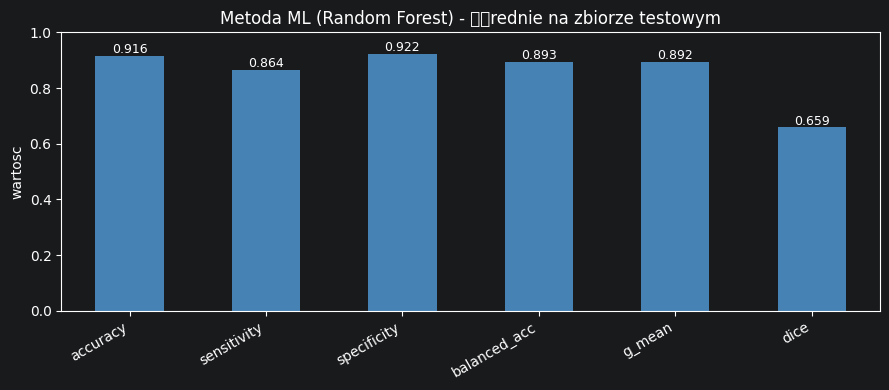

In [29]:
pokaz_wykres_slupkowy(wyniki_rf, "Metoda ML (Random Forest) - ﷿﷿rednie na zbiorze testowym")

In [30]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

if torch.backends.mps.is_available():
    URZADZENIE = "mps"
elif torch.cuda.is_available():
    URZADZENIE = "cuda"
else:
    URZADZENIE = "cpu"
torch.manual_seed(42)


class PodwojnaKonwolucja(nn.Module):
    def __init__(self, kanaly_wejsciowe, kanaly_wyjsciowe):
        super().__init__()
        self.warstwy = nn.Sequential(
            nn.Conv2d(kanaly_wejsciowe, kanaly_wyjsciowe, 3, padding=1),
            nn.BatchNorm2d(kanaly_wyjsciowe),
            nn.ReLU(inplace=True),
            nn.Conv2d(kanaly_wyjsciowe, kanaly_wyjsciowe, 3, padding=1),
            nn.BatchNorm2d(kanaly_wyjsciowe),
            nn.ReLU(inplace=True),
        )

    def forward(self, wejscie):
        return self.warstwy(wejscie)


class UNet(nn.Module):
    def __init__(self, kanaly_wejsciowe, bazowa_liczba_filtrow):
        super().__init__()
        b = bazowa_liczba_filtrow

        self.enkoder1 = PodwojnaKonwolucja(kanaly_wejsciowe, b)
        self.enkoder2 = PodwojnaKonwolucja(b, b * 2)
        self.enkoder3 = PodwojnaKonwolucja(b * 2, b * 4)
        self.enkoder4 = PodwojnaKonwolucja(b * 4, b * 8)
        self.pooling = nn.MaxPool2d(2)

        self.podnoszenie3 = nn.ConvTranspose2d(b * 8, b * 4, 2, stride=2)
        self.dekoder3 = PodwojnaKonwolucja(b * 8, b * 4)
        self.podnoszenie2 = nn.ConvTranspose2d(b * 4, b * 2, 2, stride=2)
        self.dekoder2 = PodwojnaKonwolucja(b * 4, b * 2)
        self.podnoszenie1 = nn.ConvTranspose2d(b * 2, b, 2, stride=2)
        self.dekoder1 = PodwojnaKonwolucja(b * 2, b)

        self.wyjscie = nn.Conv2d(b, 1, 1)

    def forward(self, wejscie):
        cecha1 = self.enkoder1(wejscie)
        cecha2 = self.enkoder2(self.pooling(cecha1))
        cecha3 = self.enkoder3(self.pooling(cecha2))
        cecha4 = self.enkoder4(self.pooling(cecha3))

        wynik = self.dekoder3(torch.cat([self.podnoszenie3(cecha4), cecha3], dim=1))
        wynik = self.dekoder2(torch.cat([self.podnoszenie2(wynik), cecha2], dim=1))
        wynik = self.dekoder1(torch.cat([self.podnoszenie1(wynik), cecha1], dim=1))
        return self.wyjscie(wynik)

In [31]:
ROZMIAR = ROZMIAR_WEJSCIA_UNET

def przygotuj_dla_unet(obraz_rgb):
    obraz_wzmocniony = przetwarzanie_wstepne(obraz_rgb).astype(np.float32) / 255.0
    return cv2.resize(obraz_wzmocniony, (ROZMIAR, ROZMIAR), interpolation=cv2.INTER_AREA)


class ZbiorObrazowSiatkowki(Dataset):
    def __init__(self, lista_danych):
        self.przyklady = []
        for dane in lista_danych:
            obraz_rgb, maska_ekspercka, maska_pola_widzenia = wczytaj_obraz(dane)
            obraz_wejsciowy = przygotuj_dla_unet(obraz_rgb)
            maska_docelowa = cv2.resize(
                maska_ekspercka.astype(np.float32),
                (ROZMIAR, ROZMIAR),
                interpolation=cv2.INTER_NEAREST,
            )
            self.przyklady.append((obraz_wejsciowy, maska_docelowa))

    def __len__(self):
        return len(self.przyklady)

    def __getitem__(self, indeks):
        obraz_wejsciowy, maska_docelowa = self.przyklady[indeks]

        if random.random() < 0.5:
            obraz_wejsciowy = obraz_wejsciowy[:, ::-1].copy()
            maska_docelowa = maska_docelowa[:, ::-1].copy()
        if random.random() < 0.5:
            obraz_wejsciowy = obraz_wejsciowy[::-1].copy()
            maska_docelowa = maska_docelowa[::-1].copy()

        tensor_obrazu = torch.from_numpy(obraz_wejsciowy)[None]
        tensor_maski = torch.from_numpy(maska_docelowa)[None]
        return tensor_obrazu, tensor_maski


zbior_treningowy_unet = ZbiorObrazowSiatkowki(dane_treningowe)
loader_treningowy_unet = DataLoader(zbior_treningowy_unet, batch_size=ROZMIAR_BATCHA_UNET, shuffle=True)

In [32]:
def strata_dice(logity, cel, epsilon=1.0):
    prawdopodobienstwo = torch.sigmoid(logity)
    licznik = 2 * (prawdopodobienstwo * cel).sum(dim=(2, 3)) + epsilon
    mianownik = prawdopodobienstwo.sum(dim=(2, 3)) + cel.sum(dim=(2, 3)) + epsilon
    return (1 - licznik / mianownik).mean()


siec = UNet(kanaly_wejsciowe=1, bazowa_liczba_filtrow=32).to(URZADZENIE)

if WCZYTAJ_GOTOWE_MODELE and os.path.exists(SCIEZKA_MODELU_UNET):
    siec.load_state_dict(torch.load(SCIEZKA_MODELU_UNET, map_location=URZADZENIE))
    siec.eval()
    print("Zaladowano U-Net z:", SCIEZKA_MODELU_UNET)
else:
    optymalizator = torch.optim.Adam(siec.parameters(), lr=1e-3)
    strata_bce = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([3.0], device=URZADZENIE))

    czas_startu = time.time()
    for numer_epoki in range(LICZBA_EPOK_UNET):
        siec.train()
        suma_strat = 0.0
        for obrazy, maski in loader_treningowy_unet:
            obrazy = obrazy.to(URZADZENIE)
            maski = maski.to(URZADZENIE)

            optymalizator.zero_grad()
            wyjscie_sieci = siec(obrazy)
            strata = strata_bce(wyjscie_sieci, maski) + strata_dice(wyjscie_sieci, maski)
            strata.backward()
            optymalizator.step()

            suma_strat += strata.item() * obrazy.size(0)

        srednia_strata = suma_strat / len(zbior_treningowy_unet)
        print(f"epoka {numer_epoki + 1:02d}/{LICZBA_EPOK_UNET}  strata={srednia_strata:.4f}")

    print("Czas treningu U-Net:", round(time.time() - czas_startu, 1), "s")
    torch.save(siec.state_dict(), SCIEZKA_MODELU_UNET)
    print("Zapisano U-Net do:", SCIEZKA_MODELU_UNET)

epoka 01/256  strata=1.5600
epoka 02/256  strata=1.3740
epoka 03/256  strata=1.3009
epoka 04/256  strata=1.2367
epoka 05/256  strata=1.1811
epoka 06/256  strata=1.1262
epoka 07/256  strata=1.0744
epoka 08/256  strata=1.0225
epoka 09/256  strata=0.9774
epoka 10/256  strata=0.9371
epoka 11/256  strata=0.8886
epoka 12/256  strata=0.8563
epoka 13/256  strata=0.8126
epoka 14/256  strata=0.7784
epoka 15/256  strata=0.7398
epoka 16/256  strata=0.7111
epoka 17/256  strata=0.6830
epoka 18/256  strata=0.6592
epoka 19/256  strata=0.6350
epoka 20/256  strata=0.6059
epoka 21/256  strata=0.6015
epoka 22/256  strata=0.5764
epoka 23/256  strata=0.5647
epoka 24/256  strata=0.5470
epoka 25/256  strata=0.5441
epoka 26/256  strata=0.5317
epoka 27/256  strata=0.5263
epoka 28/256  strata=0.5079
epoka 29/256  strata=0.5102
epoka 30/256  strata=0.5017
epoka 31/256  strata=0.4903
epoka 32/256  strata=0.4952
epoka 33/256  strata=0.4920
epoka 34/256  strata=0.4780
epoka 35/256  strata=0.4816
epoka 36/256  strata

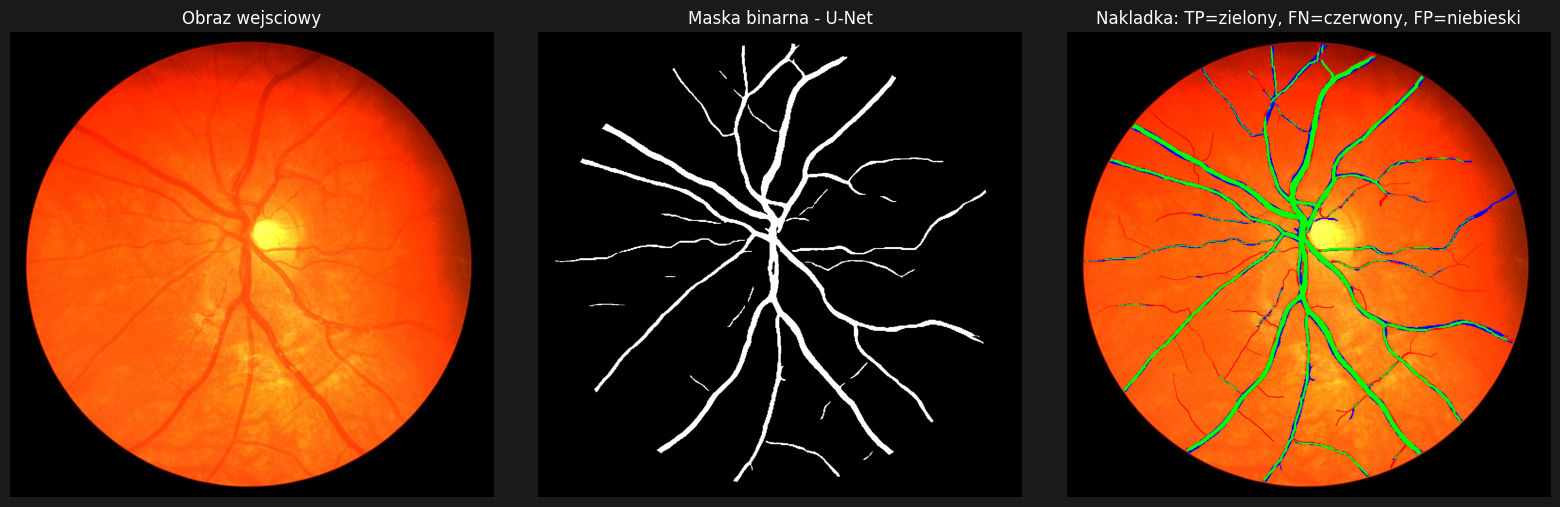

In [33]:
@torch.no_grad()
def predykcja_unet(obraz_rgb, maska_pola_widzenia, prog=0.5):
    siec.eval()
    wysokosc, szerokosc = maska_pola_widzenia.shape

    obraz_wejsciowy = przygotuj_dla_unet(obraz_rgb)
    tensor_wejscia = torch.from_numpy(obraz_wejsciowy)[None, None].to(URZADZENIE)

    prawdopodobienstwo = torch.sigmoid(siec(tensor_wejscia))[0, 0].cpu().numpy()
    prawdopodobienstwo = cv2.resize(prawdopodobienstwo, (szerokosc, wysokosc), interpolation=cv2.INTER_LINEAR)

    predykcja = (prawdopodobienstwo > prog) & maska_pola_widzenia
    predykcja = morphology.remove_small_objects(predykcja, 30)
    return predykcja


obraz_rgb, maska_ekspercka, maska_pola_widzenia = wczytaj_obraz(dane_testowe[0])
predykcja_un = predykcja_unet(obraz_rgb, maska_pola_widzenia)
pokaz_nakladke(obraz_rgb, predykcja_un, maska_ekspercka, maska_pola_widzenia, tytul="U-Net")

In [34]:
wyniki_unet = ocen_metode(predykcja_unet, dane_testowe, nazwa="U-Net")
wyniki_unet.round(4)

,accuracy,sensitivity,specificity,precision,balanced_acc,g_mean,dice,mcc,TP,FP,FN,TN
Image_11L,0.9621,0.8103,0.9749,0.7311,0.8926,0.8888,0.7687,0.7493,41283.000,15187.00,9662.0,590193.0
Image_11R,0.9609,0.8319,0.9718,0.7133,0.9019,0.8992,0.7681,0.7495,42364.000,17024.00,8558.0,586991.0
Image_12L,0.9432,0.8193,0.9583,0.7063,0.8888,0.8861,0.7586,0.7292,54664.000,22730.00,12059.0,522860.0
Image_12R,0.9473,0.7845,0.9669,0.7404,0.8757,0.8709,0.7618,0.7326,55114.000,19326.00,15137.0,564020.0
Image_13L,0.9525,0.7448,0.9731,0.7332,0.8590,0.8513,0.7390,0.7129,43747.000,15915.00,14990.0,576093.0
Image_13R,0.9478,0.7233,0.9708,0.7175,0.8471,0.8380,0.7204,0.6916,43724.000,17218.00,16726.0,572676.0
Image_14L,0.9553,0.7773,0.9752,0.7779,0.8762,0.8706,0.7776,0.7527,51188.000,14615.00,14667.0,574583.0
Image_14R,0.9524,0.7523,0.9729,0.7405,0.8626,0.8555,0.7463,0.7201,40897.000,14331.00,13469.0,515404.0
MEAN,0.9527,0.7805,0.9705,0.7325,0.8755,0.8701,0.7551,0.7297,46622.625,17043.25,13158.5,562852.5


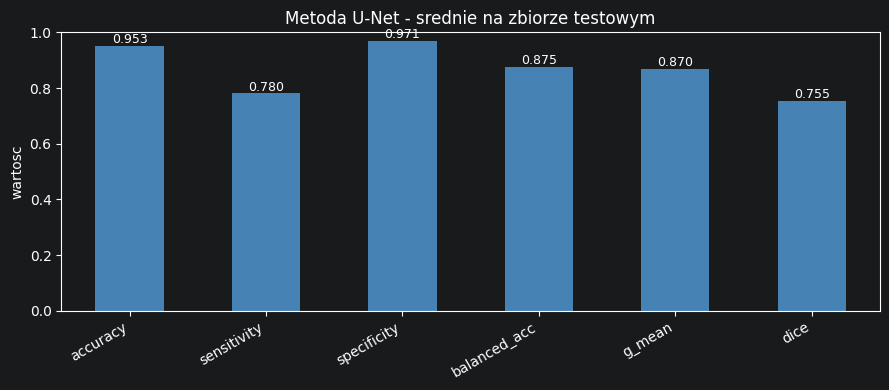

In [35]:
pokaz_wykres_slupkowy(wyniki_unet, "Metoda U-Net - srednie na zbiorze testowym")

In [36]:
def wiersz_srednich(tabela, nazwa):
    nazwy_metryk = ["accuracy", "sensitivity", "specificity",
                    "balanced_acc", "g_mean", "dice", "mcc"]
    wiersz = tabela.loc["MEAN", nazwy_metryk].copy()
    wiersz.name = nazwa
    return wiersz


porownanie = pd.DataFrame([
    wiersz_srednich(wyniki_klasyczne, "Frangi"),
    wiersz_srednich(wyniki_rf, "RandomForest"),
    wiersz_srednich(wyniki_unet, "U-Net"),
])
porownanie.round(4)

,accuracy,sensitivity,specificity,balanced_acc,g_mean,dice,mcc
Frangi,0.9450,0.6627,0.9746,0.8187,0.8032,0.6915,0.6635
RandomForest,0.9164,0.8641,0.9220,0.8930,0.8924,0.6585,0.6380
U-Net,0.9527,0.7805,0.9705,0.8755,0.8701,0.7551,0.7297


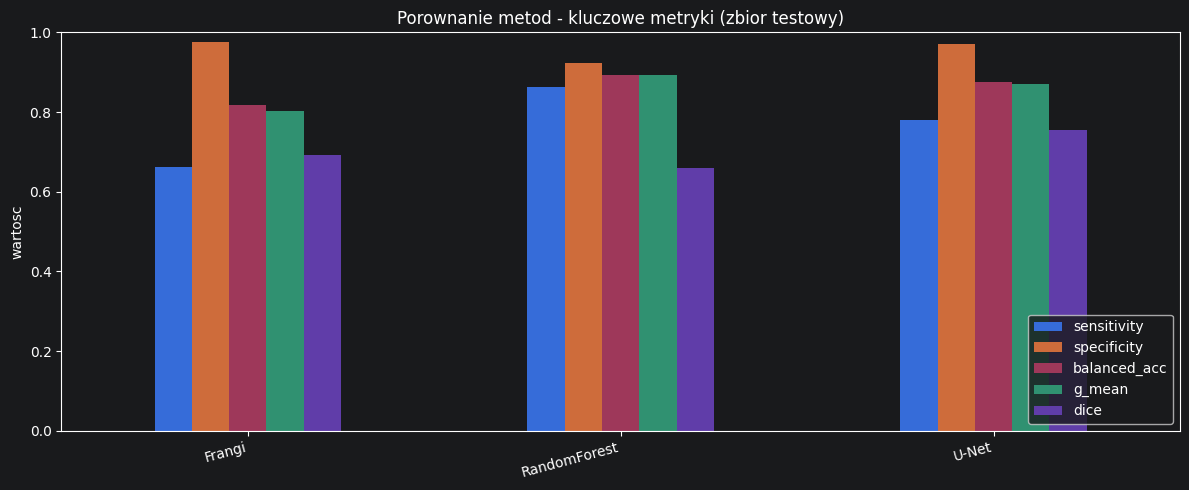

In [37]:
os_wykresu = porownanie[["sensitivity", "specificity", "balanced_acc", "g_mean", "dice"]].plot(
    kind="bar", figsize=(12, 5))
os_wykresu.set_title("Porownanie metod - kluczowe metryki (zbior testowy)")
os_wykresu.set_ylabel("wartosc")
os_wykresu.set_ylim(0, 1)
os_wykresu.legend(loc="lower right")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

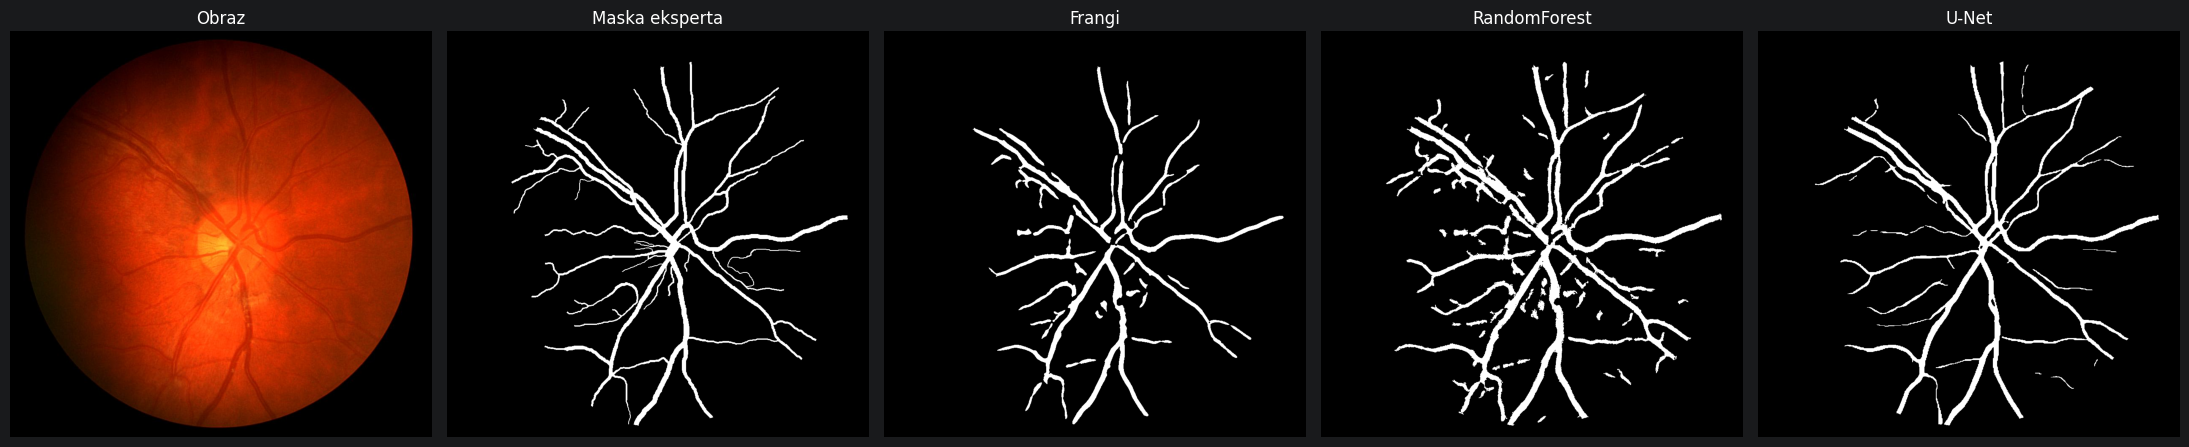

In [38]:
obraz_rgb, maska_ekspercka, maska_pola_widzenia = wczytaj_obraz(dane_testowe[7])
predykcje = {
    "Frangi": metoda_klasyczna(obraz_rgb, maska_pola_widzenia),
    "RandomForest": predykcja_random_forest(obraz_rgb, maska_pola_widzenia),
    "U-Net": predykcja_unet(obraz_rgb, maska_pola_widzenia),
}

figura, osie = plt.subplots(1, 5, figsize=(22, 5))
osie[0].imshow(obraz_rgb)
osie[0].set_title("Obraz")
osie[1].imshow(maska_ekspercka & maska_pola_widzenia)
osie[1].set_title("Maska eksperta")
for numer, (nazwa, predykcja) in enumerate(predykcje.items(), start=2):
    osie[numer].imshow(predykcja & maska_pola_widzenia)
    osie[numer].set_title(nazwa)
for pojedyncza_os in osie:
    pojedyncza_os.axis("off")
plt.tight_layout()
plt.show()